<a href="https://colab.research.google.com/github/Dhanushyapalaparvi/manual-dcgan-implementation/blob/main/DCGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/jessicali9530/celeba-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ysrisaidhanush
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset


100%|██████████| 1.33G/1.33G [00:11<00:00, 126MB/s]


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms,datasets
from PIL import Image
import pandas as pd
import os

STATS = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
BATCH_SIZE = 64
IMAGE_SIZE = 64
CHANNELS_IMG = 3
Z_DIM = 100
FEATURE_GEN = 64
FEATURE_DISC = 64
NUM_CLASSES = 40

In [4]:
class CelebAConditionalDataset(Dataset):
    def __init__(self,root_dir,attr_csv,transform = None):
        self.root_dir = root_dir
        self.annotations = pd.read_csv(attr_csv)
        self.transform = transform
    def __len__(self):
        return len(self.annotations)
    def __getitem__(self, index):
        img_path = os.path.join(self.root_dir, self.annotations.iloc[index, 0])
        image = Image.open(img_path).convert("RGB")
        attr_values = self.annotations.iloc[index, 1:].values.astype(float)
        attributes = torch.tensor((attr_values + 1) / 2).float()

        if self.transform:
            image = self.transform(image)
        return image, attributes
transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(*STATS),
])
dataset = CelebAConditionalDataset(
    root_dir="celeba-dataset/img_align_celeba/img_align_celeba",
    attr_csv="celeba-dataset/list_attr_celeba.csv",
    transform=transform
)

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)


In [5]:
class Generator(nn.Module):
  def __init__(self,z_dim,num_classes,img_channels,feature_g):
    super(Generator,self).__init__()
    self.label_embed = nn.Sequential(
        nn.Linear(num_classes,num_classes),
        nn.Unflatten(1,(num_classes,1,1))
    )
    # layer 1 transpose convolution becoz cannot upsample when the image is 1x1
    self.initial = nn.Sequential(
        nn.ConvTranspose2d(z_dim+num_classes,feature_g*8,4,1,0),
        nn.BatchNorm2d(feature_g*8),
        nn.ReLU(True)
    )
    self.up_blocks = nn.ModuleList([
        self._upsample_block(feature_g*8,feature_g*4),  #layer 2
        self._upsample_block(feature_g*4,feature_g*2),   #layer 3
        self._upsample_block(feature_g*2,feature_g)    #layer 4
    ])
    # final layer
    self.final = nn.Sequential(
        nn.Upsample(scale_factor = 2),
        nn.Conv2d(feature_g,img_channels,kernel_size=3,stride=1,padding=1),
        nn.Tanh()
    )
  def _upsample_block(self,in_channels,out_channels):
      return nn.Sequential(
        nn.Upsample(scale_factor = 2),
        nn.Conv2d(in_channels,out_channels,3,1,1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(True)
    )
  def forward(self,noise,labels):
      embedding = self.label_embed(labels)
      x = torch.cat([noise,embedding],dim=1)
      x = self.initial(x)
      for block in self.up_blocks:
        x = block(x)
      return self.final(x)


In [6]:
from torch.nn.utils import spectral_norm

In [7]:
class Discriminator(nn.Module):
  def __init__(self,img_channels,num_classes,feature_d):
    super(Discriminator,self).__init__()
    self.label_embed = nn.Sequential(
        nn.Linear(num_classes,64*64),
        nn.Unflatten(1,(1,64,64))
    )
    self.disc = nn.Sequential(
        # layer 1 64x64 -> 32x32
        spectral_norm(nn.Conv2d(img_channels+1,feature_d,4,2,1)),
        nn.LeakyReLU(0.2),
        # layer 2 32x32 -> 16x16
        self._block(feature_d,feature_d*2),
        # layer 3 16x16 -> 8x8
        self._block(feature_d*2,feature_d*4),
        # layer 4 8x8 -> 4x4
        self._block(feature_d*4,feature_d*8),
        # final layer 4x4 -> 1x1
        spectral_norm(nn.Conv2d(feature_d*8,1,4,1,0)),
        nn.Sigmoid()
    )
  def _block(self,in_channels,out_channels):
      return nn.Sequential(
          spectral_norm(nn.Conv2d(in_channels,out_channels,4,2,1)),
          nn.LeakyReLU(0.2)
      )
  def forward(self,img,labels):
        embedding = self.label_embed(labels)
        x = torch.cat([img,embedding],dim=1)
        return self.disc(x)

In [8]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
gen = Generator(Z_DIM,NUM_CLASSES,CHANNELS_IMG,FEATURE_GEN).to(device)
disc = Discriminator(CHANNELS_IMG,NUM_CLASSES,FEATURE_DISC).to(device)
opt_gen = optim.Adam(gen.parameters(),lr = 2e-4,betas = (0.5,0.999))
opt_disc = optim.Adam(disc.parameters(),lr = 2e-4,betas = (0.5,0.999))
criterion = nn.BCELoss()
fixed_noise = torch.randn(8,Z_DIM,1,1).to(device)
fixed_labels = torch.zeros(8,NUM_CLASSES).to(device)
fixed_labels[:,31] = 1.0
fixed_labels[:,24] = 1

In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_PATH = "/content/drive/MyDrive/DCGAN_CelebA"
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

Mounted at /content/drive


In [10]:
def save_checkpoint(epoch, gen, disc, opt_gen, opt_disc, filename="checkpoint.pth.tar"):
    print("=> Saving checkpoint")
    checkpoint = {
        "state_dict_gen": gen.state_dict(),
        "state_dict_disc": disc.state_dict(),
        "optimizer_gen": opt_gen.state_dict(),
        "optimizer_disc": opt_disc.state_dict(),
        "epoch": epoch,
    }
    torch.save(checkpoint, os.path.join(SAVE_PATH, filename))

In [11]:
NUM_EPOCHS = 20
for epoch in range(NUM_EPOCHS):
    for batch_idx, (real, labels) in enumerate(loader):
        real = real.to(device)
        labels = labels.to(device).float()
        cur_batch_size = real.shape[0]
        #1. Train Discriminator
        disc.zero_grad()
        # Real images + real labels
        output_real = disc(real, labels).view(-1)
        loss_disc_real = criterion(output_real, torch.ones_like(output_real))
        # Fake images + real labels
        noise = torch.randn(cur_batch_size, Z_DIM, 1, 1).to(device)
        fake = gen(noise, labels)
        output_fake = disc(fake.detach(), labels).view(-1)
        loss_disc_fake = criterion(output_fake, torch.zeros_like(output_fake))
        loss_disc = (loss_disc_real + loss_disc_fake) / 2
        loss_disc.backward()
        opt_disc.step()
        # 2. Train Generator
        gen.zero_grad()
        output = disc(fake, labels).view(-1)
        loss_gen = criterion(output, torch.ones_like(output))
        loss_gen.backward()
        opt_gen.step()
        # Print stats every 100 batches
        if batch_idx % 100 == 0:
            print(f"Epoch [{epoch}/{NUM_EPOCHS}] Batch {batch_idx}/{len(loader)} "
                  f"Loss D: {loss_disc:.4f}, loss G: {loss_gen:.4f}")
    save_checkpoint(epoch, gen, disc, opt_gen, opt_disc, filename=f"checkpoint_ep{epoch}.pth.tar")

Epoch [0/20] Batch 0/3166 Loss D: 0.7130, loss G: 0.6852
Epoch [0/20] Batch 100/3166 Loss D: 0.5850, loss G: 1.1135
Epoch [0/20] Batch 200/3166 Loss D: 0.6963, loss G: 0.8466
Epoch [0/20] Batch 300/3166 Loss D: 0.5281, loss G: 1.4575
Epoch [0/20] Batch 400/3166 Loss D: 0.6071, loss G: 1.1798
Epoch [0/20] Batch 500/3166 Loss D: 0.6624, loss G: 0.8857
Epoch [0/20] Batch 600/3166 Loss D: 0.6066, loss G: 0.9840
Epoch [0/20] Batch 700/3166 Loss D: 0.4496, loss G: 1.1645
Epoch [0/20] Batch 800/3166 Loss D: 0.6104, loss G: 0.9312
Epoch [0/20] Batch 900/3166 Loss D: 0.7044, loss G: 1.0160
Epoch [0/20] Batch 1000/3166 Loss D: 0.6319, loss G: 0.9382
Epoch [0/20] Batch 1100/3166 Loss D: 0.6361, loss G: 0.8443
Epoch [0/20] Batch 1200/3166 Loss D: 0.6421, loss G: 0.9313
Epoch [0/20] Batch 1300/3166 Loss D: 0.6440, loss G: 0.8652
Epoch [0/20] Batch 1400/3166 Loss D: 0.6934, loss G: 0.8688
Epoch [0/20] Batch 1500/3166 Loss D: 0.6560, loss G: 1.0099
Epoch [0/20] Batch 1600/3166 Loss D: 0.6796, loss G:

In [12]:
def load_checkpoint(checkpoint_file, gen, disc, opt_gen, opt_disc):
    print("=> Loading checkpoint")
    checkpoint = torch.load(checkpoint_file, map_location=device)
    gen.load_state_dict(checkpoint["state_dict_gen"])
    disc.load_state_dict(checkpoint["state_dict_disc"])
    opt_gen.load_state_dict(checkpoint["optimizer_gen"])
    opt_disc.load_state_dict(checkpoint["optimizer_disc"])
    return checkpoint["epoch"]

# Usage:
# start_epoch = load_checkpoint("/content/drive/MyDrive/DCGAN_CelebA/checkpoint.pth.tar", gen, disc, opt_gen, opt_disc)

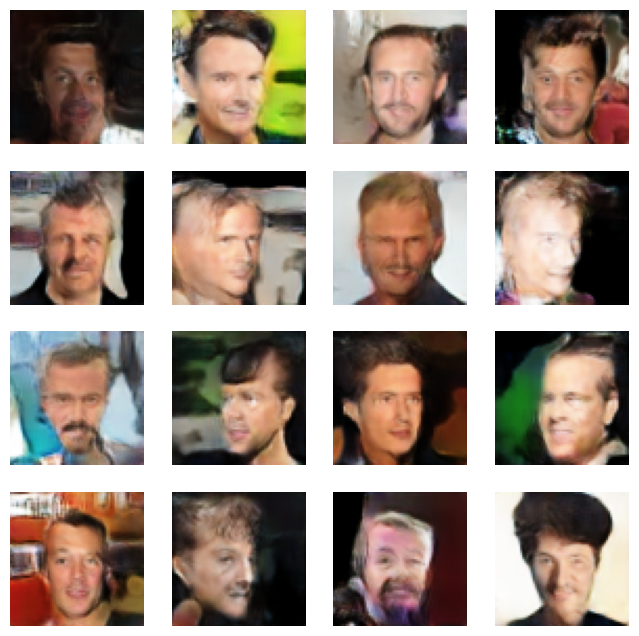

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def show_generated_images(generator, num_images=16):
    generator.eval() # Set to evaluation mode
    with torch.no_grad():
        noise = torch.randn(num_images, Z_DIM, 1, 1).to(device)
        test_labels = torch.zeros(num_images, NUM_CLASSES).to(device)
        test_labels[:, 20] = 1.0 # Male
        test_labels[:, 31] = 1.0 # Smiling
        test_labels[:, 24] = 0.0 # Beard
        fake_images = generator(noise, test_labels)
        fake_images = (fake_images * 0.5) + 0.5
        fake_images = fake_images.cpu().detach().numpy()
        plt.figure(figsize=(8, 8))
        for i in range(num_images):
            plt.subplot(4, 4, i+1)
            plt.imshow(np.transpose(fake_images[i], (1, 2, 0)))
            plt.axis('off')
        plt.show()
show_generated_images(gen)

reinitializing shell: a shell which continues from last epoch and last checkpoint

In [ ]:
gen = Generator(Z_DIM, NUM_CLASSES, CHANNELS_IMG, FEATURE_GEN).to(device)
disc = Discriminator(CHANNELS_IMG, NUM_CLASSES, FEATURE_DISC).to(device)

opt_gen = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_disc = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))

# Load the saved data
checkpoint_path = "/content/drive/MyDrive/DCGAN_CelebA/checkpoint_ep19.pth.tar"
last_epoch = load_checkpoint(checkpoint_path, gen, disc, opt_gen, opt_disc)
print(f"Resumed from epoch {last_epoch}")